In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

In [2]:
# Parameters

E=1
dm2 = 1
theta =0.195
sin_2th   = np.sin(2*theta)
cos_2th   = np.cos(2*theta)
omega = dm2/(4.0*E)

bx = omega * np.sin(2 * theta)
by = 0.0
bz = -omega * np.cos(2 * theta)

# number of nu #
N = 2

In [3]:
def interaction_matrix(N, dm2, E):
    """
    Build Jij = (dm2 / 4E) * (1 - cos(theta_ij)),
    with theta_ij = arccos(0.9) * |i-j|/(N-1).
    """
    i = np.arange(N)
    dij = np.abs(i[:, None] - i[None, :])   # |i-j|
    theta = np.arccos(0.9) * dij / (N - 1)
    J = (dm2 / (4.0 * E)) * (1.0 - np.cos(theta))
    return J

In [4]:
# -------------------------------------------------
# Add vacuum evolution to an existing circuit
# -------------------------------------------------
def add_vacuum_evolution(qc, n, bx, by, bz, N):
    """
    Add n first-order vacuum steps to the circuit.

    Each step applies:
        exp[-i (bx X_i + by Y_i + bz Z_i)]
    approximately as
        RX(2bx) RY(2by) RZ(2bz)
    on every qubit i.
    """
    for _ in range(n):
        for q in range(N):
            qc.rx(2.0 * bx, q)
            qc.ry(2.0 * by, q)
            qc.rz(2.0 * bz, q)


# -------------------------------------------------
# Add interaction evolution to an existing circuit
# -------------------------------------------------
def add_interaction_evolution(qc, n, J, N):
    """
    Add n first-order interaction steps to the circuit.

    For each pair (i,j), apply
        exp[-i Jij (XX + YY + ZZ)]
    as
        RXX(2 Jij) RYY(2 Jij) RZZ(2 Jij)
    """
    for _ in range(n):
        for i in range(N):
            for j in range(i + 1, N):
                phi = 2.0 * J[i, j]
                qc.rxx(phi, i, j)
                qc.ryy(phi, i, j)
                qc.rzz(phi, i, j)

In [5]:
# backend = AerSimulator()
# shots = 4096
# n_steps_max = 40

# for n in range(n_steps_max + 1):
#     qc = build_full_circuit(qc0, n=n, bx=bx, by=by, bz=bz, J=J, N=N)
#     tqc = transpile(qc, backend)
#     counts = backend.run(tqc, shots=shots).result().get_counts()
#     print(f"t = {n:2d}, counts = {counts}")

In [23]:
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit_aer import AerSimulator

initial_bits = [0, 1]

P_inv = [[] for _ in range(N)]
times = []

backend = AerSimulator()
shots = 4096
n_steps_max = 40
J = interaction_matrix(N, dm2, E)
qc0=QuantumCircuit(N,N)
qc0.x(1)  ## Qubit1 is nu_mu
for n in range(n_steps_max + 1):
    qc=qc0.copy()
    #add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)
    add_interaction_evolution(qc, n=n, J=J, N=N)
#     tqc = transpile(qc, backend)
#     counts = backend.run(tqc, shots=shots).result().get_counts()

    qc.measure(range(N), range(N))

    tqc = transpile(qc, backend)
    counts = backend.run(tqc, shots=shots).result().get_counts()

    p_inv_t = [0.0] * N

    for bitstring, c in counts.items():
        prob = c / shots

        for q in range(N):
            bit_q = int(bitstring[-1 - q])
            if bit_q != initial_bits[q]:
                p_inv_t[q] += prob

    times.append(n)

    for q in range(N):
        P_inv[q].append(p_inv_t[q])

    print(
        f"t = {n:2d} | "
        f"q0_inv = {p_inv_t[0]:.4f}, "
        f"q1_inv = {p_inv_t[1]:.4f} "
        
    )

t =  0 | q0_inv = 0.0000, q1_inv = 0.0000 
t =  1 | q0_inv = 0.0029, q1_inv = 0.0029 
t =  2 | q0_inv = 0.0120, q1_inv = 0.0120 
t =  3 | q0_inv = 0.0217, q1_inv = 0.0217 
t =  4 | q0_inv = 0.0427, q1_inv = 0.0427 
t =  5 | q0_inv = 0.0632, q1_inv = 0.0632 
t =  6 | q0_inv = 0.0837, q1_inv = 0.0837 
t =  7 | q0_inv = 0.1187, q1_inv = 0.1187 
t =  8 | q0_inv = 0.1428, q1_inv = 0.1428 
t =  9 | q0_inv = 0.1907, q1_inv = 0.1907 
t = 10 | q0_inv = 0.2302, q1_inv = 0.2302 
t = 11 | q0_inv = 0.2769, q1_inv = 0.2769 
t = 12 | q0_inv = 0.3137, q1_inv = 0.3137 
t = 13 | q0_inv = 0.3652, q1_inv = 0.3652 
t = 14 | q0_inv = 0.4141, q1_inv = 0.4141 
t = 15 | q0_inv = 0.4810, q1_inv = 0.4810 
t = 16 | q0_inv = 0.5232, q1_inv = 0.5232 
t = 17 | q0_inv = 0.5627, q1_inv = 0.5627 
t = 18 | q0_inv = 0.6243, q1_inv = 0.6243 
t = 19 | q0_inv = 0.6704, q1_inv = 0.6704 
t = 20 | q0_inv = 0.7036, q1_inv = 0.7036 
t = 21 | q0_inv = 0.7417, q1_inv = 0.7417 
t = 22 | q0_inv = 0.7871, q1_inv = 0.7871 
t = 23 | q0

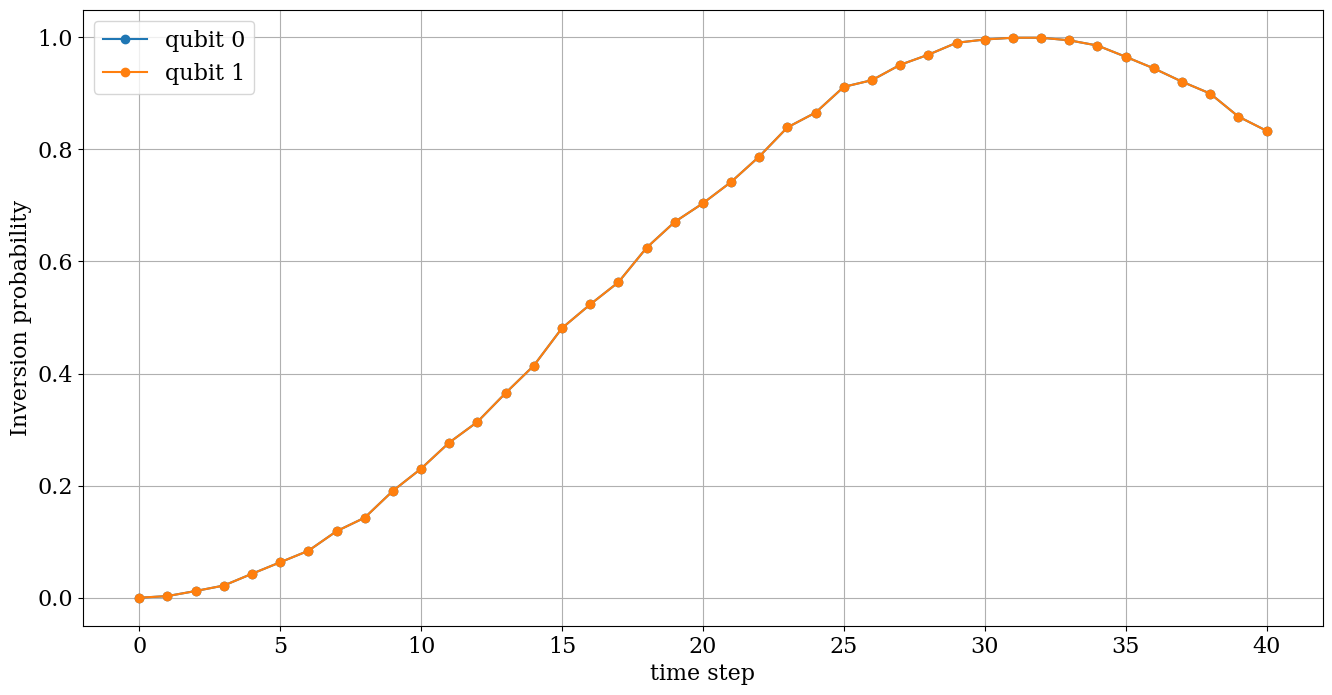

In [24]:
for q in range(N):
    plt.plot(times, P_inv[q], marker='o', label=f'qubit {q}')

plt.xlabel('time step')
plt.ylabel('Inversion probability')
plt.legend()
plt.grid(True)
plt.show()

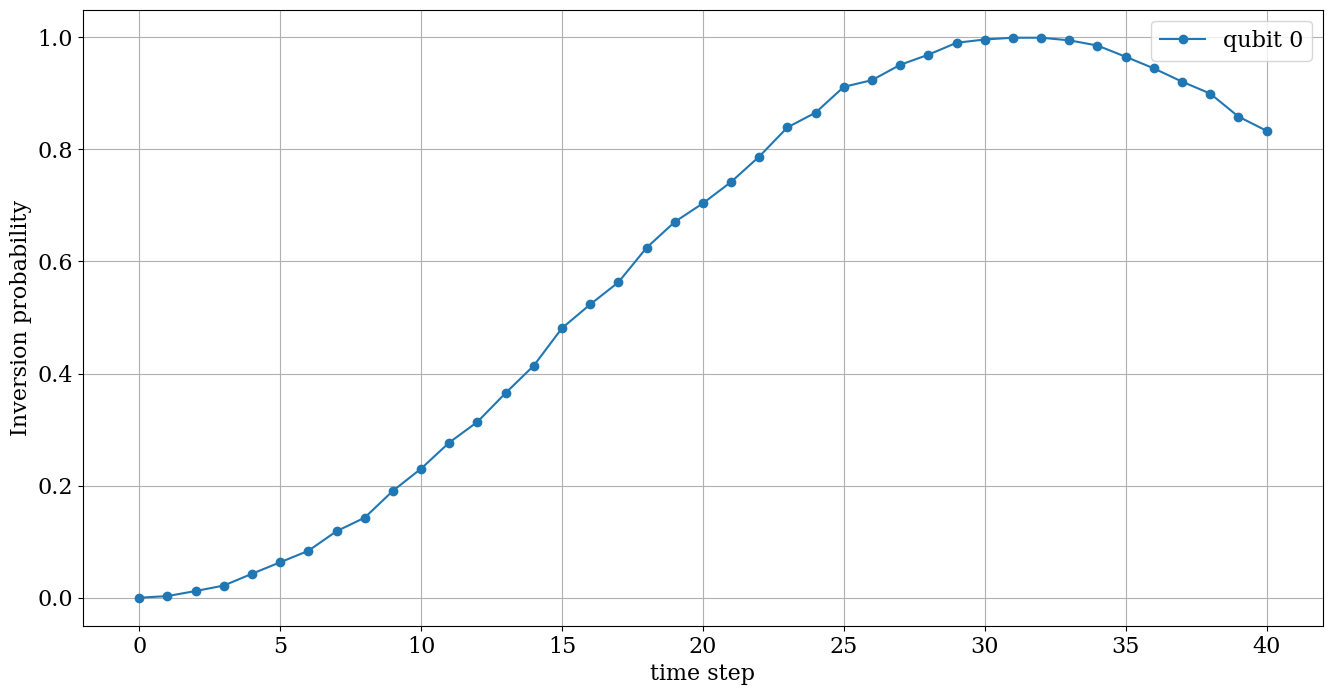

In [25]:
plt.plot(times, P_inv[0], marker='o', label='qubit 0')

plt.xlabel('time step')
plt.ylabel('Inversion probability')
plt.legend()
plt.grid(True)
plt.show()

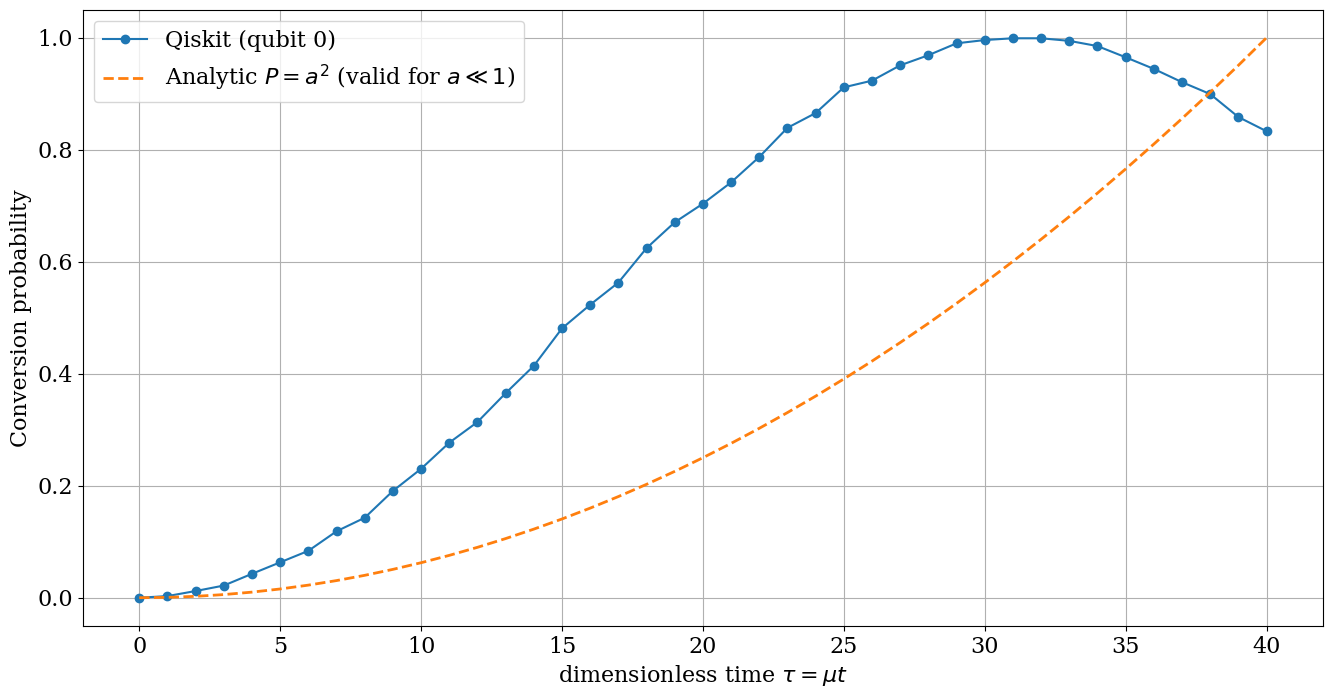

In [26]:
import numpy as np
import matplotlib.pyplot as plt

times = np.array(times)

# Qiskit result
plt.plot(times, P_inv[0],
         marker='o',
         label='Qiskit (qubit 0)')

# Analytic result (small-t only)
J_pq = J[0, 1]
mu   = dm2 / (4.0 * E)

a = (J_pq) * times
P_analytic = a**2

mask = a < 1.0   # validity region

plt.plot(times[mask], P_analytic[mask],
         linestyle='--',
         linewidth=2,
         label=r'Analytic $P=a^2$ (valid for $a\ll1$)')

plt.xlabel(r'dimensionless time $\tau=\mu t$')
plt.ylabel('Conversion probability')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
%load_ext autoreload
%autoreload 2
%autosave 0
%precision %g

import sys, os, glob, time
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.lines as lines
import functools as ft
import numpy as np
import numpy.random as rnd
import scipy.integrate as integ
import qiskit as qk
import qiskit_aer as aer
import qiskit_algorithms as qalgo
import qiskit_ibm_runtime as qkrun
import qiskit_experiments as qkexp
import qiskit_braket_provider as braket

# Launch Wolfram language interface
# from wolframclient.evaluation import WolframLanguageSession
# from wolframclient.language import wl, wlexpr
# wl_session = WolframLanguageSession()

from tqdm import tqdm

import sys

sys.path.append("../")

# Directories
# if os.uname().sysname == 'Linux':
#     base_dir = os.path.expanduser("~/sn-quant/")
# else:
#     base_dir = os.path.expanduser("~/Dropbox/sn-quant/jk/")

#base_dir = os.path.join("../", "joachim")
#os.chdir(base_dir)

# set up matplotlib
%matplotlib inline
# matplotlib.rcParams['text.usetex']    = True
# matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
matplotlib.rcParams['font.family']    = 'serif'
matplotlib.rcParams['font.size']      = '16'
# matplotlib.rcParams['figure.figsize'] = 6.4, 4.8
matplotlib.rcParams['figure.figsize'] = 16, 8

# Unit conversion and physical constants
class my_units:
    # Energy and mass
    eV     = 1.
    keV    = 1.e3
    MeV    = 1.e6
    GeV    = 1.e9
    TeV    = 1.e12
    PeV    = 1.e15
    kg     = 5.62e35*eV
    grams  = 0.001*kg
    Kelvin = 8.617333262e-5       # PDG 2022
    Joule  = 1/1.602176634e-19*eV # PDG 2022 [exact]
    erg    = 1e-7*Joule
    
    # Length and time
    m     = 5.076e6
    meter = m
    km    = 1000*m
    cm    = 0.01*m
    nm    = 1.e-9*m
    fm    = 1.e-15*m
    AU    = 1.4960e11*m
    pc    = 30.857e15*m
    kpc   = 1.e3*pc
    Mpc   = 1.e6*pc
    Gpc   = 1.e9*pc
    ly    = 9460730472580800*m  # light year
    sec   = 1.523e15
    hours = 3600*sec
    days  = 24*hours
    yrs   = 365*days
    Hz    = 1./sec
    kHz   = 1.e3*Hz
    MHz   = 1.e6*Hz
    GHz   = 1.e9*Hz
    
    barn  = 1.e-24*cm**2
    pb    = 1.e-36*cm**2
    fb    = 1.e-39*cm**2
    
    # Various astrophysical constants
    GN    = 6.708e-39/1e18  # eV^-2, Newton's constant
    MPl   = 1.22093e19*GeV   # Planck mass, PDG 2013
    Msun  = 1.989e30*kg
    Rsun  = 6.9551e8*meter
    
    # cosmology
    h        = 0.674                         # according to Planck 2018
    H0       = h * 100. * km / sec/ Mpc      # Hubble parameter
    rho_c0   = 3. * H0**2/(8. * np.pi * GN)  # critical density today, Kolb Turner eq. (3.14)
    Omega_dm = 0.12 / h**2                   # dark matter density, Planck 2018
    
    # particle physics
    alpha_em = (1./137.035999139)            # electromagnetic fine structure constant (PDG 2018)
    GF       = 1.166378e-5 / GeV**2          # Fermi constant (PDG 2022)
    s2thW    = 1.03232 * 0.23121             # sin^2 \theta_W(M_Z) from PDG 2022; \kappa from https://arxiv.org/abs/1608.02671
    m_e      = 0.5109989461 * MeV            # electron mass (PDG 2018)
    m_mu     = 105.6583745 * MeV             # muon mass (PDG 2018)
    m_tau    = 1776.86 * MeV                 # tau mass (PDG 2018)
    m_p      = 938.2720813 * MeV             # proton mass (PDG 2018)
    m_n      = 939.565413 * MeV              # neutron mass (PDG 2018)
    m_u      = 931.4940954 * MeV             # atomic mass unit (PDG 2018)
    m_pi0    = 134.9768 * MeV                # neutral pion mass (PDG 2020)
    tau_mu   = 2.1969811e-6 * sec            # muon lifetime (PDG 2018)
    gA       = 1.26                          # axial coupling constant of the proton
    
    # PDG codes
    pdg_nu_e      = 12
    pdg_nu_mu     = 14
    pdg_nu_tau    = 16
    pdg_e         = 11
    pdg_mu        = 13
    pdg_tau       = 15
    pdg_gamma     = 22
    pdg_pip       = 211
    pdg_pi0       = 111
    pdg_KL        = 130
    pdg_Kp        = 321
    pdg_Dp        = 411
    pdg_D0        = 421
    pdg_Dp2s_2460 = 415
    pdg_D02s_2460 = 425
    pdg_Dsp       = 431
    pdg_Dsps      = 433
    pdg_Ds2s_2573 = 435
    
u = my_units()

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]])
sigma_1 = np.array([[0, 1],  [1,  0]])
sigma_2 = np.array([[0,-1j], [1j, 0]])
sigma_3 = np.array([[1, 0],  [0, -1]])


"""
Functions taken from bipolar-oscillations.ipynb, Raffelt–Sigl Polarization-Vector Approach to Collective Oscillations
"""

def P_osc_RS(t_table, theta, omega, lam, J, initial_flavors=None, alpha=None):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           omega:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           initial_flavors: an array of length n_modes indicating the initial flavor of
                    each neutrino ('e', 'x', or 'a'). If any neutrino has flavor 'a',
                    an angle alpha must be specified.
           alpha:   initial superposition for neutrinos in flavor 'a'
    """
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1.])
    Emu = np.array([0, 0, -1.])
    B   = np.real(np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)]))
    L   = np.real(np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)]))
    
    ini_state = np.where(omega>0, Ee[:,None], Emu[:,None])
    if initial_flavors is not None:
        for f in initial_flavors:
            if f not in ['e','x','mu','a']:
                raise ValueError(f'Unknown flavor: {f}')
            if f == 'a' and alpha is None:
                raise ValueError('Initial superposition for neutrinos in flavor "a" not specified')
        ini_state[:,initial_flavors=='e']  = Ee[:,None]
        ini_state[:,initial_flavors=='x']  = Emu[:,None]
        ini_state[:,initial_flavors=='mu'] = Emu[:,None]
        ini_state[:,initial_flavors=='a']  = np.array([np.sin(2*alpha), 0, np.cos(2*alpha)])[:,None]
        # FIXME I'm not sure this is correct
        
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            res[3*k:3*k+3] = np.cross(omega[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res

    return integ.solve_ivp(f, (t_table[0],t_table[-1]), ini_state.T.flatten(), t_eval=t_table)

def P_osc_RS_bipolar(t_table, theta, omega, lam, J, eps=0.1):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach for
       a bipolar system.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           omega:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           eps:     asymmetry between neutrinos and anti-neutrinos"""
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller, Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1+eps])
    Emu = np.array([0, 0, -1+eps])
    B   = np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)])
    L   = np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)])
    
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = (0+0j)*np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            s  = 1 if k < n_modes//2 else -1
            res[3*k:3*k+3] = np.cross(s*omega[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res
            
    E0 = np.concatenate((np.tile(Ee,n_modes//2), np.tile(Emu,n_modes//2)))
    return integ.solve_ivp(f, (t_table[0],t_table[-1]), E0, t_eval=t_table)    

def U_self_int(theta):
   """the exponential of the neutrino interaction Hamiltonian,
      see Friedland & Lunardini, https://arxiv.org/abs/hep-ph/0304055
   """
   return np.array([[np.exp(-1j*theta), 0,                          0,                          0],
                  [0,                 0.5*( 1+np.exp(-1j*theta)), 0.5*(-1+np.exp(-1j*theta)), 0],
                  [0,                 0.5*(-1+np.exp(-1j*theta)), 0.5*( 1+np.exp(-1j*theta)), 0],
                  [0,                 0,                          0,                          np.exp(-1j*theta)]])



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Autosave disabled


In [21]:
### Calculation from MFT

omega = np.zeros(2)   # no vacuum term
lam   = 0.0           # no matter term
theta = 0.0           # irrelevant when omega=0

initial_flavors = np.array(['e', 'x'])

# Provide dummy alpha (required by function implementation)
sol = P_osc_RS(times, theta, omega, lam, J,
               initial_flavors=initial_flavors,
               alpha=0.0)

# Extract solution array
P_all = sol.y                    # shape: (3*n_modes, n_times)

n_modes = J.shape[0]

# Reshape to (mode, component, time)
P = P_all.reshape(n_modes, 3, -1)

# z-component of mode 0 (initial ν_e)
Pz0 = P[0, 2, :]

# Conversion probability ν_e → ν_mu (ν_x)
P_mft = 0.5 * (1 - Pz0)

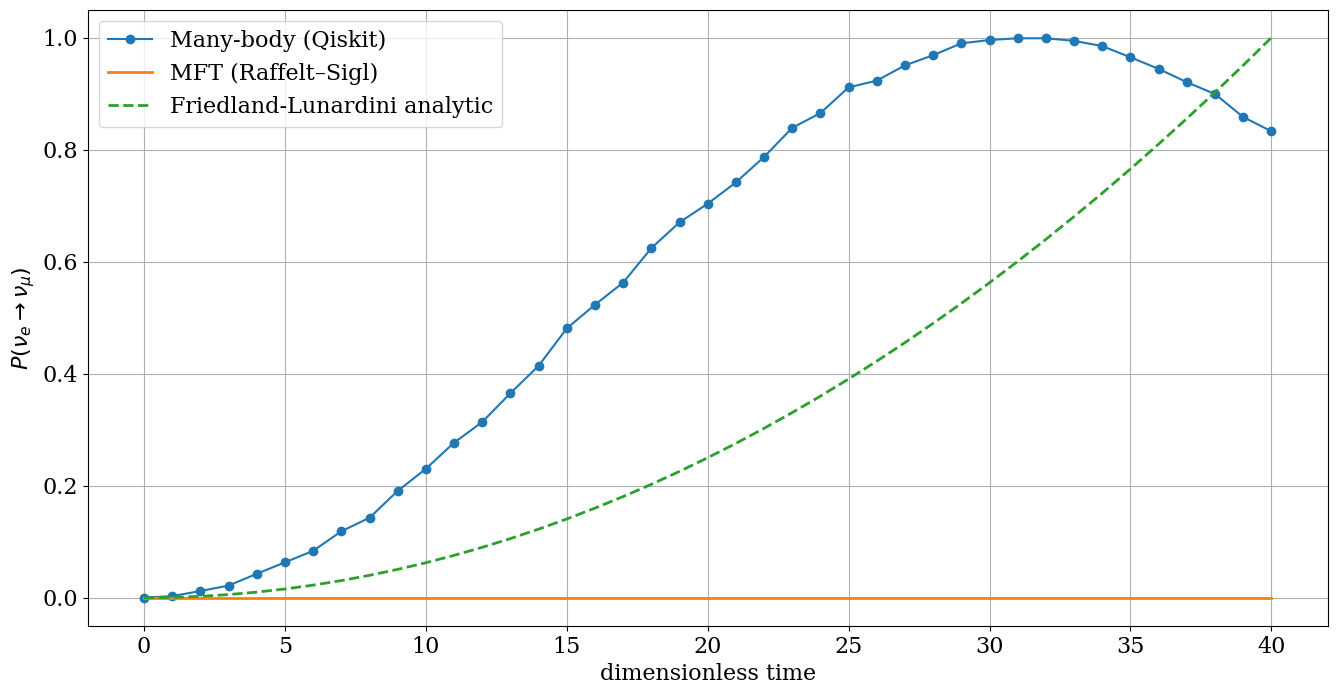

In [28]:
import matplotlib.pyplot as plt
import numpy as np

times = np.array(times)

# --- Many-body ---
plt.plot(times, P_inv[0],
         marker='o',
         label='Many-body (Qiskit)')

# --- MFT ---
plt.plot(times, P_mft,
         linestyle='-',
         linewidth=2,
         label='MFT (Raffelt–Sigl)')

# --- Analytic (Eq. 15) ---
plt.plot(times, P_analytic,
         linestyle='--',
         linewidth=2,
         label='Friedland-Lunardini analytic')

plt.xlabel(r'dimensionless time')
plt.ylabel(r'$P(\nu_e \to \nu_\mu)$')
plt.legend()
plt.grid(True)
plt.show()